In [ ]:
import sqlite3#python db
import pandas as pd#panda lib
import matplotlib.pyplot as plt#plot lib
import warnings#lib to ignore large warings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv("student_performance.csv")

In [ ]:
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
print("\n First 3 rows")
df.head(3)

Dataset loaded: 30 students, 13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

 First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn = sqlite3.connect("college.db")
#connects or create a db connection
cursor = conn.cursor()
#use sql queries in py
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
#creates a table automatically using the data frame records
cursor.execute("SELECT COUNT(*) FROM students")
#query to fetch the count of records
count=cursor.fetchone()[0]
#retives the first result row and [0] gets the first value

print(f"Database 'college.db' created")
print(f"Table 'students' has {count} rows")


Database 'college.db' created
Table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")

columns_info = cursor.fetchall()

print("Table Structure of 'students':")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("_" * 38)

for col in columns_info:
    print(f"{col[1]:<25} {col[2]:<12}")

Table Structure of 'students':
Column Name               Data Type   
______________________________________
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"\n{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [ ]:
query2 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students ORDER BY student_id DESC LIMIT 5; """
result1 = run_query(query2,"")

 student_id           name       department  math_score  attendance_percentage
       1030 Akanksha Yadav Computer Science          91                     95
       1029     Nitin Jain       Mechanical          75                     84
       1028  Sunita Pillai            Civil          60                     73
       1027  Gaurav Shukla Computer Science          84                     87
       1026     Rekha Nair      Electronics          72                     82


In [ ]:
query1 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students  LIMIT 10; """
result1 = run_query(query1,"Query1:First 10 Students (SELECT+LIMIT)")


Query1:First 10 Students (SELECT+LIMIT)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [15]:
query3="""SELECT student_id,name,department,programming_score FROM students ORDER BY student_id  LIMIT 5; """
result3 = run_query(query3,"Query3:First 5 Students (SELECT+ORDER BY+LIMIT)")


Query3:First 5 Students (SELECT+ORDER BY+LIMIT)

 student_id         name       department  programming_score
       1001 Aarav Sharma Computer Science                 91
       1002  Priya Patel Computer Science                 79
       1003  Rohit Verma      Electronics                 55
       1004  Sneha Reddy       Mechanical                 48
       1005   Arjun Nair Computer Science                 95


In [16]:
run_query("select name,department,math_score,programming_score  from students  where programming_score between 55 and 75",description="")

         name  department  math_score  programming_score
  Rohit Verma Electronics          65                 55
  Vikram Iyer Electronics          80                 72
 Ritu Agarwal Electronics          87                 69
Harish Pillai Electronics          64                 58
   Rekha Nair Electronics          72                 63


,name,department,math_score,programming_score
0,Rohit Verma,Electronics,65,55
1,Vikram Iyer,Electronics,80,72
2,Ritu Agarwal,Electronics,87,69
3,Harish Pillai,Electronics,64,58
4,Rekha Nair,Electronics,72,63


In [ ]:
run_query("select name,department,math_score,programming_score  from students  where programming_score not between 55 and 75",description="")


In [18]:
run_query("SELECT student_id,name,attendance_percentage FROM students WHERE attendance_percentage > 75")

 student_id           name  attendance_percentage
       1001   Aarav Sharma                     92
       1002    Priya Patel                     87
       1003    Rohit Verma                     78
       1004    Sneha Reddy                     95
       1005     Arjun Nair                     90
       1007    Kiran Kumar                     85
       1008    Divya Singh                     96
       1010     Ananya Das                     98
       1011    Vikram Iyer                     83
       1012    Pooja Gupta                     80
       1013     Suresh Rao                     88
       1014  Kavya Nambiar                     91
       1016   Ritu Agarwal                     93
       1018 Swati Kulkarni                     94
       1019 Deepak Chauhan                     77
       1020   Nisha Kapoor                     89
       1022    Tanvi Mehta                     97
       1024  Preeti Saxena                     86
       1025      Amit Bose                     91


,student_id,name,attendance_percentage
0,1001,Aarav Sharma,92
1,1002,Priya Patel,87
2,1003,Rohit Verma,78
3,1004,Sneha Reddy,95
4,1005,Arjun Nair,90
5,1007,Kiran Kumar,85
6,1008,Divya Singh,96
7,1010,Ananya Das,98
8,1011,Vikram Iyer,83
9,1012,Pooja Gupta,80


In [21]:
dept_data={
    'dept_code': ['CS','EC','ME','CE'],
    'dept_name': ['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr. Sharma','Dr. Reddy','Dr. Patel','Dr. Kumar'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}

dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))

Created 'departments' table:
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical  Dr. Patel         1972      60
       CE            Civil  Dr. Kumar         1965      60


In [ ]:
quet_join="""
    SELECT
        s.name,
        s.math_score,
        d.dept_name,
        d.hod_name,
        d.established
    FROM students AS s
    INNER JOIN departments AS d
      ON s.dept_code = d.dept_code
    ORDER BY s.math_score DESC
    LIMIT 8
"""

<BarContainer object of 4 artists>

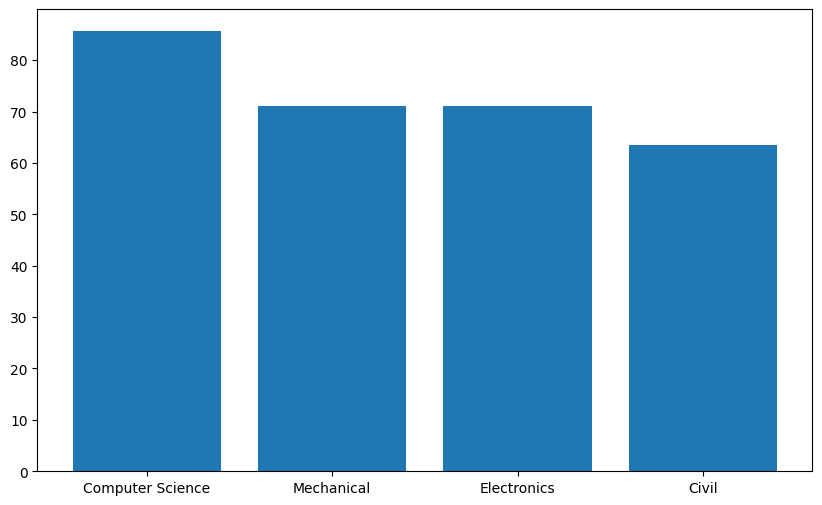

In [22]:
from numpy import char
chart1_sql ="""
     SELECT department , ROUND(AVG(math_score),2) AS avg_math_score
     FROM students
     GROUP BY department
     ORDER BY avg_math_score DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
ax.bar(chart1_data['department'],chart1_data['avg_math_score'])

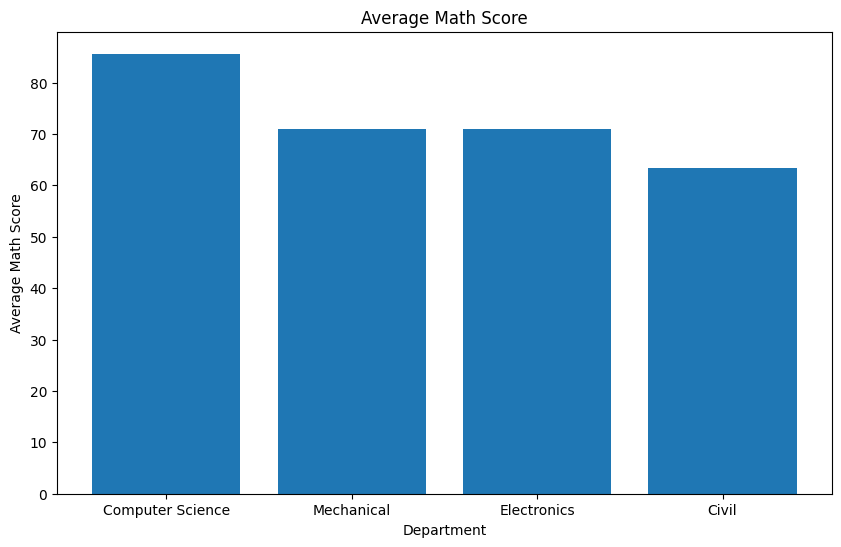

In [23]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
chart1_df = pd.read_sql_query(chart1_sql,conn)
fig , ax = plt.subplots(figsize=(10,6))
ax.bar(chart1_df['department'],chart1_df['avg_math'])
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score')
plt.show()